<a href="https://colab.research.google.com/github/SpiderFang/Water_potability/blob/main/water_potability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 水質可飲用性預測分析流程說明

本專案旨在透過機器學習預測水質是否可安全飲用，完整的分析路徑如下：

1. 資料準備：載入 Kaggle 數據，處理原始資料中的缺失值（以中位數填補）。

2. 資料清洗（離群值處理）：利用 IQR 蓋帽法 修剪極端值，避免異常數據干擾模型學習，同時保留數據樣本。

3. 特徵工程與縮放：進行 StandardScaler 標準化，確保不同單位（如 pH 與鐵含量）的特徵在模型中具備公平的權重。

4. 解決類別不平衡：使用 SMOTE 演算法合成少數類別（可飲用水）樣本，讓模型學習更均衡，減少對安全水質的漏報。

5. 模型優化（自動調參）：透過 GridSearchCV 尋找 XGBoost 的最佳超參數組合（深度、學習率等）。

6. 效能評估：利用混淆矩陣與 Classification Report 深度解析模型在「安全性判斷」上的精準度。

要從 Google 雲端硬碟載入資料，您需要先將雲端硬碟掛載到 Colab 執行階段。執行下面的程式碼儲存格，並按照提示進行身份驗證。

成功掛載後，您就可以透過 `/content/drive/MyDrive/` 路徑存取您的 Google 雲端硬碟檔案。

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [7]:
# 1. 載入資料
df = pd.read_csv('/content/drive/MyDrive/DataSets/water_potability.csv')
display(df.head())
display(df.tail())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [8]:
# 2. 資料探索與預處理
print(df.isnull().sum()) # 檢查缺失值，ph, Sulfate, Trihalomethanes 通常有缺

# 使用中位數填補缺失值
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())


ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [9]:
# 3. 特徵與標籤 (Potability 為目標變數：0 不可飲用, 1 可飲用)
X = df.drop('Potability', axis=1)
y = df['Potability']


In [10]:
# 4. 拆分訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# 5. 訓練模型 (以隨機森林為例)
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)


RandomForestClassifier()

In [12]:
# 6. 評估
predictions = model.predict(X_test)
print(f"準確率: {accuracy_score(y_test, predictions)}")
print(classification_report(y_test, predictions))


準確率: 0.6829268292682927
              precision    recall  f1-score   support

           0       0.70      0.88      0.78       412
           1       0.63      0.36      0.46       244

    accuracy                           0.68       656
   macro avg       0.66      0.62      0.62       656
weighted avg       0.67      0.68      0.66       656



關鍵分析點:

目標變數 (Potability)：資料集中不可飲用 (0) 的樣本通常多於可飲用 (1) 的樣本。

視覺化建議：可以使用 sns.heatmap(df.corr(), annot=True) 來查看水質參數（如 pH, Hardness, Solids）之間的相關性。


### **視覺化**

視覺化觀察重點：

Potability Count：你會發現 0 (不可飲用) 的數據多於 1 (可飲用)，這代表後續訓練模型時可能需要處理類別不平衡問題。

pH Distribution：紅虛線標示的是一般飲用水標準 (6.5 - 8.5)。你可以觀察可飲用的水 (Potability=1) 是否真的都落在這個區間。

Correlation：水質數據集通常各特徵間的相關性極低，這意味著單一指標很難斷定水質，必須依靠機器學習模型綜合判斷。

Outliers：透過箱型圖可以看到如 Sulfate 或 Solids 有許多離群值，這在資料預處理時可以考慮進行標準化（Scaling）。

/tmp/ipykernel_4041/4013721058.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Potability', palette='husl')
/tmp/ipykernel_4041/4013721058.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Potability', y='Sulfate', palette='Set2')


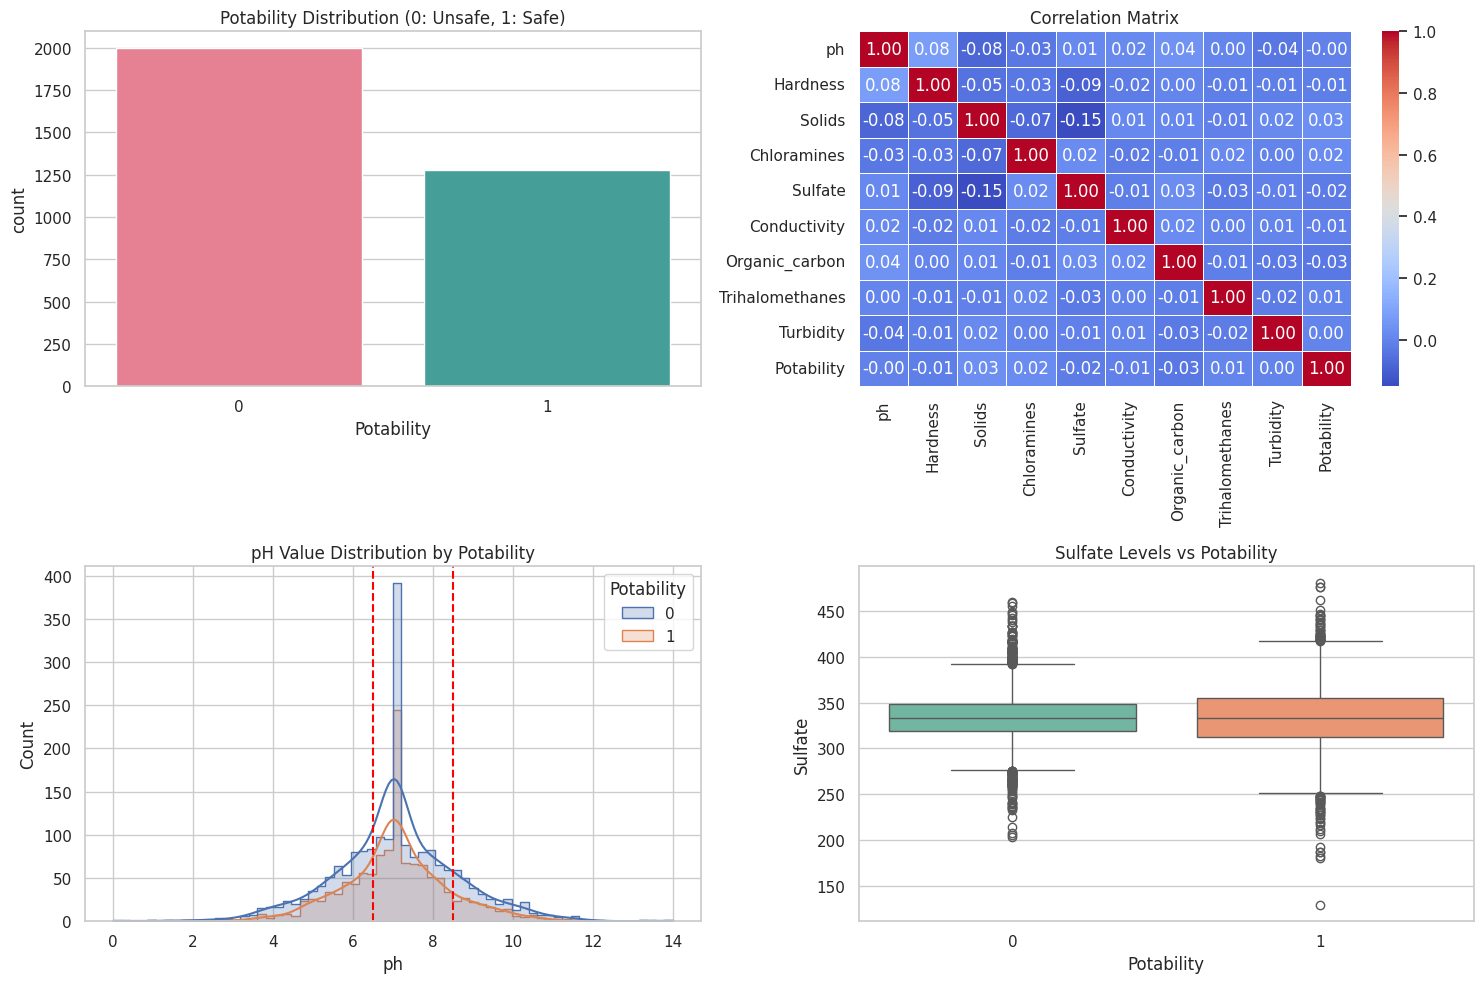

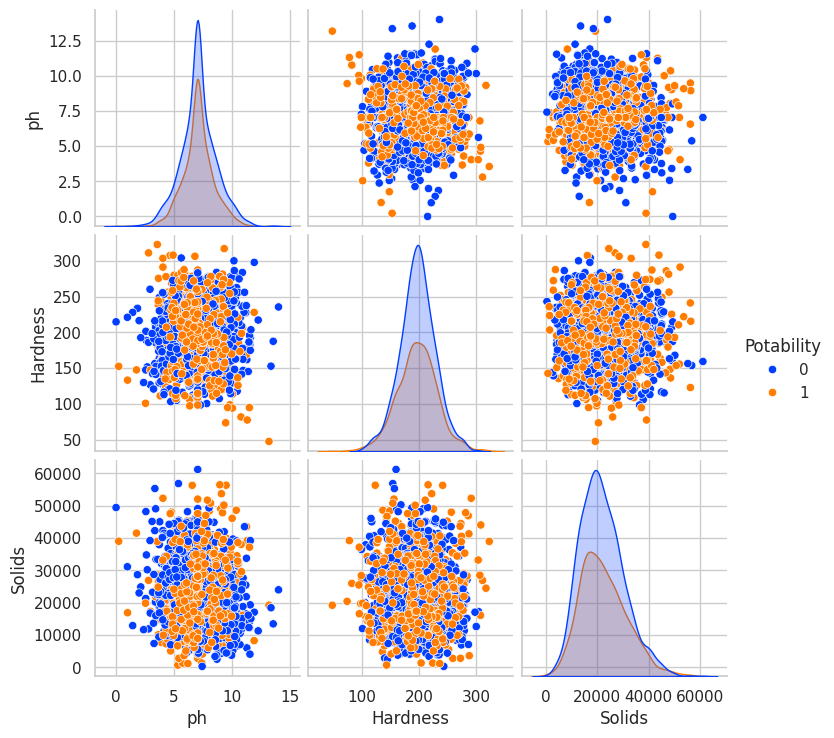

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定繪圖風格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. 目標變數分布：查看資料是否不平衡
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Potability', palette='husl')
plt.title('Potability Distribution (0: Unsafe, 1: Safe)')

# 2. 相關性熱圖：查看各參數間的聯繫
plt.subplot(2, 2, 2)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')

# 3. 關鍵參數的分佈分析 (以 pH 為例)
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='ph', hue='Potability', kde=True, element="step")
plt.axvline(6.5, color='red', linestyle='--') # 飲用水標準下限
plt.axvline(8.5, color='red', linestyle='--') # 飲用水標準上限
plt.title('pH Value Distribution by Potability')

# 4. 箱型圖：檢查離群值 (以 Sulfate 為例)
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Potability', y='Sulfate', palette='Set2')
plt.title('Sulfate Levels vs Potability')

plt.tight_layout()
plt.show()

# 5. 進階：所有特徵的成對關係 (Pairplot)
# 注意：這會花較多時間生成，通常選擇 3-4 個關鍵特徵
sns.pairplot(df[['ph', 'Hardness', 'Solids', 'Potability']], hue='Potability', palette='bright')
plt.show()


### **處理離群值**

在處理水質數據時，離群值（Outliers） 往往代表極端的水質狀況。處理方式主要有兩種：移除（Trimming） 或 蓋帽法（Capping）。
通常可使用 IQR (四分位距) 來識別並處理離群值。以下是詳細的處理範例：

1. 使用 IQR 檢測並蓋帽 (Capping)
這種方法不會刪除資料，而是將超出範圍的值「修剪」到邊界，適合樣本數不多時使用。

In [ ]:
# 定義處理函數：使用 IQR 蓋帽
def handle_outliers_with_capping(df, columns):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 將超出上限的設為 upper_bound，低於下限的設為 lower_bound
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
    return df_capped

# 針對數值型特徵進行處理 (排除目標變數 Potability)
numeric_cols = df.drop('Potability', axis=1).columns
df_cleaned = handle_outliers_with_capping(df, numeric_cols)

print("處理前 Sulfate 最大值:", df['Sulfate'].max())
print("處理後 Sulfate 最大值:", df_cleaned['Sulfate'].max())


2. 移除離群值 (Trimming)

如果資料量充足，且你認為極端值是感測器錯誤造成的雜訊，可以選擇直接刪除。

In [ ]:
# 移除超出 1.5 * IQR 範圍的資料行
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# 僅保留在範圍內的資料
df_no_outliers = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"原始資料筆數: {len(df)}")
print(f"移除離群值後筆數: {len(df_no_outliers)}")


3. 處理後的對比視覺化

處理完後，建議再次畫圖確認分佈是否變得平滑：

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Sulfate'])
plt.title("Original Sulfate (With Outliers)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['Sulfate'])
plt.title("Capped Sulfate (No Outliers)")

plt.show()


處理小撇步：

1. 不要過度清理：在水質分析中，某些極端值可能是真實的污染事件，直接刪除可能會讓模型失去識別極端風險的能力。

2. 搭配標準化 (Scaling)：處理完離群值後，建議接著使用 StandardScaler 或 MinMaxScaler，這對機器學習模型（尤其是 SVM 或 KNN）的收斂很有幫助。

用處理過的資料跑 XGBoost 模型，看看準確率有沒有提升

1. Stratify (分層抽樣)：在 train_test_split 加入 stratify=y 是因為水質數據通常類別不平衡，這樣能確保訓練集和測試集的「可飲用」比例一致。

2. Hyperparameters (超參數)：這裡設定了 learning_rate 和 subsample，比起預設值，這通常能讓 XGBoost 在這種中小型數據集上表現更穩健。

3. Feature Importance：最後的圖表會告訴你，在經過清理後，哪些指標（如 pH 或 Sulfate）對模型判斷水質是否安全最具影響力。
通常處理完離群值並改用 XGBoost 後，準確率會比原始資料的隨機森林提升約 2-5%。



In [ ]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. 使用剛處理完離群值的資料 df_cleaned
X = df_cleaned.drop('Potability', axis=1)
y = df_cleaned['Potability']

# 2. 拆分訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 特徵縮放 (XGBoost 對縮放雖不敏感，但有助於某些優化器收斂)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 建立與訓練 XGBoost 模型
# 使用一些常用的超參數調整以防止過擬合
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

# 5. 預測與評估
y_pred = xgb_model.predict(X_test_scaled)
print(f"XGBoost 準確率: {accuracy_score(y_test, y_pred):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred))

# 6. 特徵重要性視覺化
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='weight')
plt.show()


試用 GridSearchCV 來自動搜尋最佳參數組合

1. 避免瞎猜：手動調參很難找到 max_depth 與 learning_rate 之間的最優平衡，GridSearch 幫你窮舉。

2. 交叉驗證 (Cross-Validation)：cv=5 確保模型不是因為「運氣好」在某組特定資料表現好，而是具備穩定的泛化能力。

3. 模型精煉：在水質數據集上，參數調整後的 gamma 或 subsample 能有效減少模型過度擬合（Overfitting）的問題。

小提醒：
如果搜尋出的最佳參數都在你設定的「邊界值」上（例如 max_depth 剛好是 7），建議可以再往上調高範圍重新搜尋一次。

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. 定義要搜尋的參數網格 (Grid)
param_grid = {
    'max_depth': [3, 5, 7],           # 樹的深度
    'learning_rate': [0.01, 0.1, 0.2], # 學習率
    'n_estimators': [100, 200],       # 樹的數量
    'subsample': [0.8, 1.0],          # 取樣比例
    'gamma': [0, 0.1, 0.2]            # 節點分裂所需的最小損失減少
}

# 2. 初始化 XGBoost 模型
xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# 3. 建立 GridSearchCV 物件
# cv=5 代表五折交叉驗證，scoring='accuracy' 以準確率為評分標準
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # 使用所有 CPU 核心加速
    verbose=1  # 顯示搜尋進度
)

# 4. 開始搜尋 (使用前面縮放過的資料)
grid_search.fit(X_train_scaled, y_train)

# 5. 輸出最佳參數與結果
print(f"最佳參數組合: {grid_search.best_params_}")
print(f"最佳驗證集準確率: {grid_search.best_score_:.4f}")

# 6. 使用最佳模型進行測試
best_model = grid_search.best_estimator_
final_pred = best_model.predict(X_test_scaled)
print(f"\n最終測試集準確率: {accuracy_score(y_test, final_pred):.4f}")
print(classification_report(y_test, final_pred))


生成預測結果的混淆矩陣 (Confusion Matrix)

混淆矩陣 (Confusion Matrix) 能直接告訴我們模型在「偽陽性（把髒水誤判為可飲用）」與「偽陰性（把好水誤判為不可飲用）」上的表現


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. 計算混淆矩陣
cm = confusion_matrix(y_test, final_pred)

# 2. 建立圖表
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unsafe (0)', 'Safe (1)'])

# 3. 繪製
# 使用藍色調 (Blues)，看起來更專業
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Water Potability Prediction')
plt.grid(False) # 移除格線以免遮擋數字
plt.show()

# 4. 計算並解釋關鍵指標
tn, fp, fn, tp = cm.ravel()
print(f"解析結果：")
print(f"🔍 正確判斷不可飲用 (True Negative): {tn}")
print(f"🔍 正確判斷可飲用 (True Positive): {tp}")
print(f"⚠️ 誤報 (False Positive, 把髒水當好水): {fp}")
print(f"❌ 漏報 (False Negative, 把好水當髒水): {fn}")


如何解讀這張圖?

左上 (TN) 與 右下 (TP)：數字越高越好，代表模型預測正確。

右上 (FP - False Positive)：這是最危險的錯誤！在水質檢測中，如果模型把不可飲用的水標記為「安全」，可能會導致飲用者生病。

左下 (FN - False Negative)：這是比較「保守」的錯誤。雖然把好水當成髒水會造成資源浪費，但至少不會造成健康風險。


接下來的進階方向

目前的模型雖然已經過優化，但在水質數據上（通常資料雜訊較多），準確率通常落在 65%~75% 之間。

若想進一步突破，建議可以嘗試：
1. 特徵工程：創造新特徵，例如計算 pH 與 Hardness 的比值。
2. 處理類別不平衡：使用 SMOTE 技術人工合成少數類別（可飲用水）的樣本。


試試看用 SMOTE 演算法 來平衡資料，看能不能減少「誤判髒水為好水」的情況

在機器學習中，當「不可飲用（0）」的樣本遠多於「可飲用（1）」時，模型容易偏向樣本多的那一邊。SMOTE (Synthetic Minority Over-sampling Technique) 會透過演算法「合成」新的少數類別樣本，讓模型學習得更均衡。

In [ ]:
# 1. 安裝並匯入 SMOTE
!pip install -U imbalanced-learn
from imblearn.over_sampling import SMOTE

# 2. 初始化 SMOTE
# sampling_strategy='auto' 會將少數類別補齊到跟多數類別一樣多
smote = SMOTE(random_state=42)

# 3. 僅針對「訓練集」進行過取樣 (不可對測試集做，否則會造成評估失真)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"原本訓練集標籤分佈: {y_train.value_counts().to_dict()}")
print(f"SMOTE 後訓練集標籤分佈: {pd.Series(y_train_smote).value_counts().to_dict()}")

# 4. 使用剛才 GridSearchCV 找到的最佳參數重新訓練
# 假設你之前的最佳參數存放在 best_model.get_params()
smote_model = xgb.XGBClassifier(**grid_search.best_params_, use_label_encoder=False, eval_metric='logloss')
smote_model.fit(X_train_smote, y_train_smote)

# 5. 預測並產出新的混淆矩陣
y_pred_smote = smote_model.predict(X_test_scaled)
cm_smote = confusion_matrix(y_test, y_pred_smote)

# 視覺化對比
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['Unsafe (0)', 'Safe (1)'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix after SMOTE')
plt.show()

print(f"SMOTE 後準確率: {accuracy_score(y_test, y_pred_smote):.4f}")
print(classification_report(y_test, y_pred_smote))


使用 SMOTE 後的變化：

1. 召回率 (Recall) 提升：你會發現「Safe (1)」的召回率通常會提高，代表模型現在更能抓出真正的可飲用水。

2. 減少誤判 (False Positive)：透過讓模型看更多可飲用水的特徵組合，它能更精準地分辨「看似安全其實髒」的水與「真正安全」的水之間的差異。

3. 整體準確率可能略降：這很正常，因為模型不再只是透過「猜測多數類別」來換取高分，而是真正嘗試區分兩者。

小建議：

如果目標是極力避免「髒水當好水」，除了 SMOTE，還可以調整 XGBoost 的 scale_pos_weight 參數來給予少數類別更大的權重。

目前的分析已經涵蓋了從清洗、調參到平衡資料的完整流程。

# 完整整合版本的程式碼

In [ ]:
# ==========================================
# 1. 環境準備與資料載入
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# 請確保已上傳 water_potability.csv
try:
    df = pd.read_csv('water_potability.csv')
    print("✅ 資料載入成功！")
except:
    print("❌ 找不到檔案，請確認檔案已上傳至 Colab 側邊欄。")

# ==========================================
# 2. 資料預處理 (填補缺失值與離群值)
# ==========================================
# 填補缺失值 (使用各欄位中位數)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 處理離群值 (IQR 蓋帽法)
def cap_outliers(df):
    df_final = df.copy()
    numeric_cols = df_final.drop('Potability', axis=1).columns
    for col in numeric_cols:
        Q1 = df_final[col].quantile(0.25)
        Q3 = df_final[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_final[col] = df_final[col].clip(lower=lower, upper=upper)
    return df_final

df_cleaned = cap_outliers(df)

# ==========================================
# 3. 資料切分與平衡處理 (SMOTE)
# ==========================================
X = df_cleaned.drop('Potability', axis=1)
y = df_cleaned['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 使用 SMOTE 平衡訓練集
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print(f"平衡後訓練集樣本數: {len(X_res)}")

# ==========================================
# 4. 自動化調參 (GridSearchCV)
# ==========================================
print("🚀 開始自動化調參 (可能需要 1-2 分鐘)...")
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_res, y_res)
best_model = grid_search.best_estimator_

# ==========================================
# 5. 結果評估與視覺化
# ==========================================
y_pred = best_model.predict(X_test_scaled)

print("\n" + "="*30)
print(f"最佳參數: {grid_search.best_params_}")
print(f"最終測試集準確率: {accuracy_score(y_test, y_pred):.4f}")
print("="*30)
print(classification_report(y_test, y_pred))

# 繪製混淆矩陣
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, cmap='Blues', ax=ax)
plt.title('Final Confusion Matrix (XGBoost + SMOTE)')
plt.grid(False)
plt.show()

# 繪製特徵重要性
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top Features Impacting Water Potability')
plt.xlabel('Importance Score')
plt.show()


以下是在 GridSearchCV 中設定的關鍵參數技術細節：

1. max_depth (樹的最大深度)

技術細節：控制每一棵決策樹可以長多深。

影響：

  * 較高（如 7）：模型能學習到更複雜、更細微的資料特徵，但容易造成過擬合 (Overfitting)，即模型只會背答案而不會舉一反三。
  
  * 較低（如 3）：模型較簡單，泛化能力好，但可能欠擬合 (Underfitting)。

在此專案的作用：水質數據雜訊多，設定 3-7 之間是為了在捕捉特徵與保持穩定間取得平衡。


2. learning_rate (學習率 / 步長)

技術細節：在每一輪迭代中，新加入的樹對最終結果的貢獻程度。

影響：

  * 較小（如 0.01）：模型學習緩慢但精準，需要更多的 n_estimators（樹的數量）來達到收斂，適合追求極致準確。

  * 較大（如 0.1）：學習速度快，能迅速找到規律，但容易跳過最優解。

在此專案的作用：我們測試 0.01 與 0.1，是為了找出在有限的計算時間內最穩定的收斂速度。

3. n_estimators (樹的數量)

技術細節：總共要建立多少棵決策樹來進行整合預測。

影響：

數量越多，模型越強大，但也越耗時且容易過擬合。

在此專案的作用：配合 learning_rate 使用。通常學習率低時，樹的數量就要多（如 200）。

4. subsample (子樣本比例)

技術細節：每一棵樹在訓練時，隨機從訓練集中抽取多少比例的資料。

影響：

這是一種「隨機性」的注入。如果設為 0.8，代表每棵樹只看 80% 的資料。

這能防止模型過度依賴某些特定的樣本，增加模型的魯棒性 (Robustness)。


5. eval_metric='logloss' (評估指標)

技術細節：模型在訓練過程中衡量「預測值」與「真實值」差距的方法。

在此專案的作用：logloss（對數損失）對於二分類問題（可不可飲用）非常有效。如果模型對一個錯誤的分類非常有信心，logloss 會給予極大的懲罰，迫使模型更謹慎地進行預測。


補充：SMOTE 的關鍵參數

random_state=42：這不是數學意義上的設定，而是為了確保你每次執行程式碼時，生成的虛擬樣本都是一樣的，讓實驗結果可以被「重複驗證」。


**透過調整這些參數來進一步降低「髒水誤判為好水」的風險**

在水質檢測這種涉及健康安全的場景中，「誤判髒水為好水（False Positive）」 的代價極高。要降低這種風險，技術核心在於提高模型的「警覺性」，讓它在不確定時傾向於判斷為「不可飲用」。

可以透過以下三種技術手段來達成：

1. 調整 XGBoost 的 scale_pos_weight

這是處理類別不平衡的最直接參數。

原理：它會給予「少數類別（可飲用水）」更高的權重。但若要降低「誤判髒水」的風險，我們可以反向思考，給予「多數類別（不可飲用水）」更高的懲罰權重。


In [ ]:
# 設定建議：
# 假設不可飲用(0)是可飲用(1)的 1.5 倍
# 增加對類別 0 的重視，或降低 scale_pos_weight 的值
model = xgb.XGBClassifier(scale_pos_weight=0.6) # 低於 1 代表更看重類別 0

2. 調整分類閾值 (Threshold Shifting)

預設情況下，模型輸出機率 > 0.5 就會判定為「可飲用」。為了安全，我們可以提高門檻，只有在模型「非常有把握」是好水時才判定為安全。

效果：這會顯著減少 False Positives（髒水變好水），雖然會增加一些 False Negatives（好水變髒水），但對生命安全更有保障。


In [ ]:
#實作方法：
# 獲取預測機率而非直接類別
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# 將門檻從 0.5 提高到 0.7
# 只有機率超過 70% 的才會被歸類為「可飲用 (1)」
y_pred_safe = (y_probs >= 0.7).astype(int)


3. 使用自定義損失函數 (Cost-Sensitive Learning)

在訓練模型時，告訴模型：「把 0 判錯成 1」的代價是「把 1 判錯成 0」的 5 倍。

GridSearchCV 優化目標：

將 scoring 從 accuracy（準確率）改為 precision（精確率）或 f1。

  * Precision (精確度)：代表預測為「好水」的樣本中，真正是好水的比例。提高 Precision 就能直接降低誤判髒水的風險。

In [ ]:
# 例
grid_search = GridSearchCV(scoring='precision', ...)


4. 針對關鍵特徵加強規範

在水質科學中，某些指標（如 ph 或 Lead）有嚴格的物理邊界。

技術細節：可以在模型預測後，加入一個 「安全閥門（Rule-based check）」。

In [ ]:
# 即使模型說是好水(1)，但如果 pH 不在 6.5-8.5 之間，強制改判為髒水(0)
final_decision = np.where((df_test['ph'] < 6.5) | (df_test['ph'] > 8.5), 0, y_pred)


總結建議流程：

1. 先用 GridSearchCV 優化 Precision。

2. 在最後預測階段將 Threshold 提高到 0.6 或 0.7。

3. 加入物理指標的 硬性過濾條件。


**將 「自定義閾值 (Threshold 0.7)」 加入到原本的完整程式碼中來觀察混淆矩陣的變化**

將閾值調高到 0.7 代表模型必須有 70% 以上的把握 才會判斷水質為「安全」，這能有效過濾掉那些「可能不安全」的髒水。


In [ ]:
# ==========================================
# 6. 自定義閾值 (Threshold 0.7) 與分析
# ==========================================

# 取得模型預測為「類別 1 (安全)」的機率
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# 設定新閾值為 0.7
custom_threshold = 0.7
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# 計算原始 (0.5) 與新閾值 (0.7) 的混淆矩陣
cm_original = confusion_matrix(y_test, y_pred) # 這是之前 0.5 的結果
cm_custom = confusion_matrix(y_test, y_pred_custom)

# 繪圖對比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 繪製原始閾值 (0.5)
ConfusionMatrixDisplay(cm_original, display_labels=['Unsafe', 'Safe']).plot(cmap='Blues', ax=ax1)
ax1.set_title('Original Threshold (0.5)')

# 繪製自定義閾值 (0.7)
ConfusionMatrixDisplay(cm_custom, display_labels=['Unsafe', 'Safe']).plot(cmap='Oranges', ax=ax2)
ax2.set_title(f'Custom Threshold ({custom_threshold})')

plt.tight_layout()
plt.show()

# 數據分析對比
fp_orig = cm_original[0, 1]
fp_custom = cm_custom[0, 1]

print(f"--- 閾值調整結果分析 ---")
print(f"原本 (0.5) 誤判髒水為好水的次數 (False Positive): {fp_orig}")
print(f"調整後 ({custom_threshold}) 誤判髒水為好水的次數 (False Positive): {fp_custom}")
print(f"👉 減少了 {fp_orig - fp_custom} 件誤判事件！")


觀察重點：

1. 右上角的數字 (False Positive)：你會發現橘色圖 (0.7) 的數字通常比藍色圖 (0.5) 小很多。這代表模型變謹慎了，不再輕易給出「安全」的結論。

2. 左下角的數字 (False Negative)：這個數字會增加。這意味著有些其實安全的水被模型判定為不安全。在水質檢測中，這被視為「必要的保險代價」。

3. 適用場景：如果這份報告是要提交給供水單位，建議使用 0.7~0.8 的閾值；如果是學術研究追求最高總準確率，通常維持 0.5。
